In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = "cleaned_output/Fitbit_vid_cleaned"

sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vid_sleep_score_cleaned.xlsx")
stress_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vid_stress_score_cleaned.xlsx")
activity_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vid_active_zone_minutes_(azm)_cleaned.xlsx")
hrv_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vid_heart_rate_variability_cleaned.xlsx")
spo2_df = pd.read_excel(f"{BASE_DIR}/Fitbit_vid_oxygen_saturation_(spo2)_cleaned.xlsx")


In [2]:
sleep_df["date"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce").dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)


In [3]:
stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce")

stress_daily = (
    stress_df
    .groupby(stress_df["date"].dt.date)["stress_score"]
    .mean()
    .reset_index()
)


In [4]:
activity_df["date"] = pd.to_datetime(activity_df["date_time"], errors="coerce").dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)


In [5]:
hrv_df["date"] = pd.to_datetime(hrv_df["timestamp"], errors="coerce").dt.date

hrv_daily = (
    hrv_df
    .groupby("date")["rmssd"]
    .mean()
    .reset_index()
)


In [10]:
spo2_df["date"] = pd.to_datetime(
    spo2_df["timestamp"],
    errors="coerce"
).dt.date


In [15]:
spo2_daily = (
    spo2_df
    .dropna(subset=["date", "average_value"])
    .groupby("date")["average_value"]
    .mean()
    .reset_index(name="avg_spo2")
)

spo2_daily.head()


,date,avg_spo2
0,2025-08-06,0.000000
1,2025-08-07,0.000000
2,2025-08-08,0.550857
3,2025-08-09,0.000000
4,2025-08-10,0.183559


In [17]:
sleep_stress = pd.merge(
    sleep_daily,
    stress_daily,
    on="date",
    how="inner"
)

sleep_stress[["sleep_score", "stress_score"]].corr()


,sleep_score,stress_score
sleep_score,1.00000,-0.27076
stress_score,-0.27076,1.00000


In [18]:
sleep_stress = pd.merge(
    sleep_daily,
    stress_daily,
    on="date",
    how="inner"
)

sleep_stress[["sleep_score", "stress_score"]].corr()


,sleep_score,stress_score
sleep_score,1.00000,-0.27076
stress_score,-0.27076,1.00000


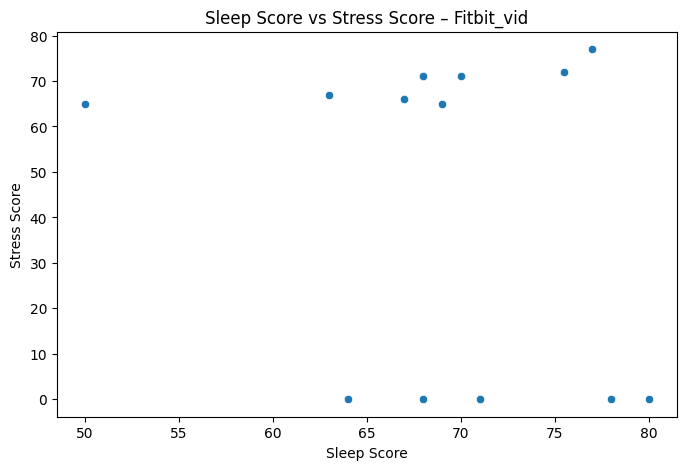

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=sleep_stress,
    x="sleep_score",
    y="stress_score"
)
plt.title("Sleep Score vs Stress Score – Fitbit_vid")
plt.xlabel("Sleep Score")
plt.ylabel("Stress Score")
plt.show()


In [20]:
activity_stress = pd.merge(
    activity_daily,
    stress_daily,
    on="date",
    how="inner"
)

activity_stress[["active_minutes", "stress_score"]].corr()


,active_minutes,stress_score
active_minutes,1.000000,-0.228866
stress_score,-0.228866,1.000000


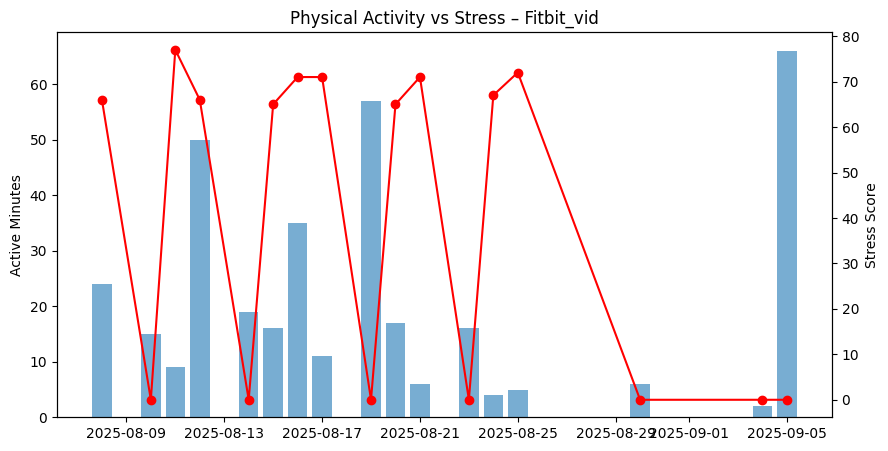

In [21]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(activity_stress["date"], activity_stress["active_minutes"], alpha=0.6)
ax1.set_ylabel("Active Minutes")

ax2 = ax1.twinx()
ax2.plot(activity_stress["date"], activity_stress["stress_score"],
         color="red", marker="o")
ax2.set_ylabel("Stress Score")

plt.title("Physical Activity vs Stress – Fitbit_vid")
plt.xticks(rotation=45)
plt.show()


In [22]:
stress_hrv = pd.merge(
    hrv_daily,
    stress_daily,
    on="date",
    how="inner"
)

stress_hrv[["rmssd", "stress_score"]].corr()


,rmssd,stress_score
rmssd,1.000000,-0.048389
stress_score,-0.048389,1.000000


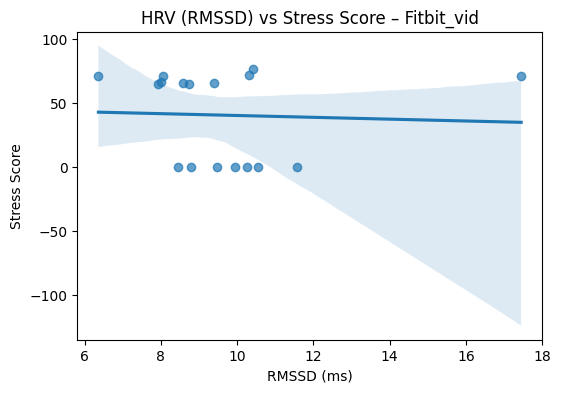

In [23]:
plt.figure(figsize=(6,4))
sns.regplot(
    data=stress_hrv,
    x="rmssd",
    y="stress_score",
    scatter_kws={"alpha": 0.7}
)
plt.title("HRV (RMSSD) vs Stress Score – Fitbit_vid")
plt.xlabel("RMSSD (ms)")
plt.ylabel("Stress Score")
plt.show()


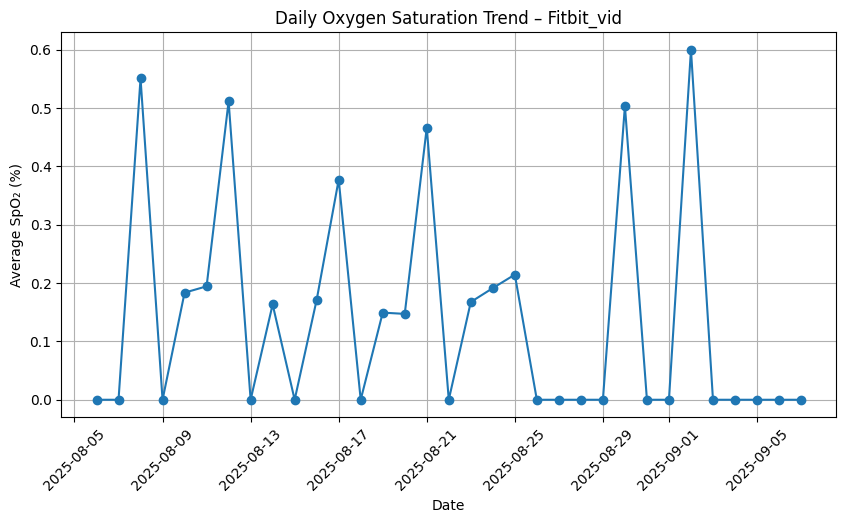

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    spo2_daily["date"],
    spo2_daily["avg_spo2"],
    marker="o"
)
plt.title("Daily Oxygen Saturation Trend – Fitbit_vid")
plt.xlabel("Date")
plt.ylabel("Average SpO₂ (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


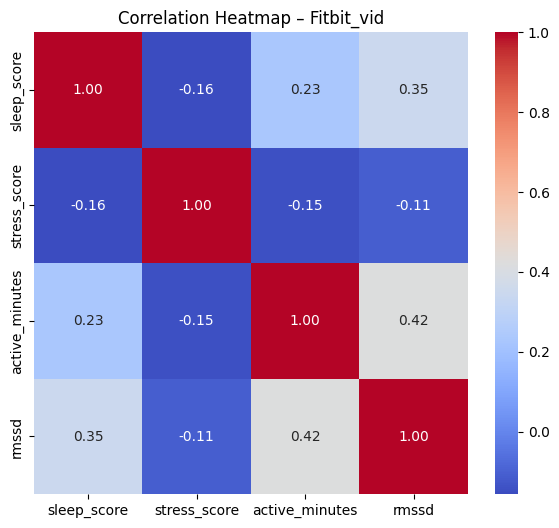

In [25]:
combined_vid = (
    sleep_daily
    .merge(stress_daily, on="date", how="inner")
    .merge(activity_daily, on="date", how="inner")
    .merge(hrv_daily, on="date", how="inner")
)

corr = combined_vid.select_dtypes(include="number").corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap – Fitbit_vid")
plt.show()
